# Project： Image Analysis and Clusting

## Overview
### Welcome to an exciting project where we bring images to life through data analysis and clustering! In this journey, we’ll take a vibrant image of a rainbow, transform it into a dataset full of colorful pixel information, and explore the beauty of data by grouping these pixels into clusters. Whether it’s using scikit-learn’s trusty KMeans or diving into custom clustering magic with PyTorch, each task is a step deeper into the art and science of image processing. Let’s paint a picture with pixels, break it down into data, and watch the patterns unfold!

## Task 1: Creating the Dataset

### Objective
Your mission is to extract valuable data from the `rainbow1.jpg` image. We will transform each pixel into a row of data containing its (x, y) coordinates and RGB color values, creating a comprehensive dataset ready for analysis and visualization.

### Steps to Follow

1. **Load the Image**: Use the `PIL` (Pillow) library to open and read the image file.
   * *Hint*: Make sure to handle images with an alpha channel (`RGBA`) by converting them to `RGB` to simplify your data.

2. **Convert to a NumPy Array**: Transform the image into a NumPy array for easy access to pixel data.

3. **Extract Coordinates and RGB Values**:
   - Create arrays for x and y coordinates using NumPy functions like `np.arange()` and `np.tile()`.
   - Reshape the image array to extract the RGB values for each pixel in a format that’s easy to work with.
   * *Hint*: The `reshape(-1, 3)` method helps flatten the array while keeping the RGB structure intact.

4. **Create a Pandas DataFrame**:
   - Combine the (x, y) coordinates and RGB values into a structured DataFrame.

5. **Inspect the DataFrame**:
   - Print out the first ten rows of the DataFrame to ensure that the data extraction was successful.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load the image - the image has been uploaded to Google colab
image_path = 'rainbow1.jpg'

# Convert the image to RGB if it's RGBA
img = Image.open(image_path).convert('RGB')
img_array = np.array(img)

# Get image dimensions
height, width, _ = img_array.shape

# Generate x, y coordinates
x_coords = np.tile(np.arange(width), height)  # Repeated for each row
y_coords = np.repeat(np.arange(height), width)  # Repeated for each column

# Extract RGB values
rgb_values = img_array.reshape(-1, 3)  # Flatten the image while keeping RGB intact

# Create a DataFrame
df = pd.DataFrame(rgb_values, columns=['R', 'G', 'B'])
df['x'] = x_coords
df['y'] = y_coords

# Display the first few rows
print(df.head(10))


    R   G   B  x  y
0  68  67  49  0  0
1  42  43  27  1  0
2  43  43  31  2  0
3  34  35  27  3  0
4  50  49  44  4  0
5  20  17  12  5  0
6  20  10   8  6  0
7  60  49  43  7  0
8  46  34  22  8  0
9  44  35  18  9  0


In [42]:
'''This code loads a picture, extracts pixel values and coordinates, then organizes the results into a DataFrame for easy examination and manipulation.
By converting the image to RGB and creating coordinates, we can determine the color and position of each pixel within it. This organized data can s
ubsequently be utilized to do further activities such as clustering, image processing, and visualization.

We start by importing the libraries needed  and then loading the image "rainbow". Then we calculate the x and y coordinates to find the location of the
pixels to create our dataset.

Our major goal for this job is to convert a rainbow image into an organized dataset. First, the image was converted
to RGB format to remove the alpha channel. This is done by relying just on color data rather than the transparency
channel. The data is then turned into a NumPy array, which allows you to access and modify the pixel data.
The np.tile() and np.repeat() functions generate arrays of x and y coordinates.
'''

'This code loads a picture, extracts pixel values and coordinates, then organizes the results into a DataFrame for easy examination and manipulation. \nBy converting the image to RGB and creating coordinates, we can determine the color and position of each pixel within it. This organized data can s\nubsequently be utilized to do further activities such as clustering, image processing, and visualization.\n\nWe start by importing the libraries needed  and then loading the image "rainbow". Then we calculate the x and y coordinates to find the location of the \npixels to create our dataset. \n\nOur major goal for this job is to convert a rainbow image into an organized dataset. First, the image was converted\nto RGB format to remove the alpha channel. This is done by relying just on color data rather than the transparency \nchannel. The data is then turned into a NumPy array, which allows you to access and modify the pixel data. \nThe np.tile() and np.repeat() functions generate arrays of 

## Task 2: Visualizing and Cleaning the Image Data

### Objective
Now that we have created a dataset from the `rainbow1.jpg` image, it's time to visualize the image and address any noise it may contain. Our goal is to print the image, identify noise, and use the dataset to remove or reduce that noise for a cleaner representation.

### Steps to Follow

1. **Visualize the Original Image**:
   - Use `matplotlib` to display the image from the dataset and observe any visible noise or artifacts.
2. **Analyze Noise**:
   - Look for patterns or outliers in the pixel data that indicate noise (e.g., isolated dark spots or random bright pixels).
3. **Filter the Dataset**:
   - Use conditions to filter out unwanted noise based on RGB values or other criteria.
4. **Reconstruct and Display the Cleaned Image**:
   - Reconstruct the image using the filtered DataFrame and visualize it to confirm that the noise has been reduced.

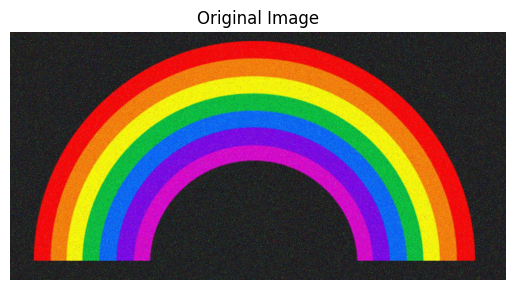

    R   G   B  x  y
0  68  67  49  0  0
1  42  43  27  1  0
2  43  43  31  2  0
3  34  35  27  3  0
4  50  49  44  4  0
5  20  17  12  5  0
6  20  10   8  6  0
7  60  49  43  7  0
8  46  34  22  8  0
9  44  35  18  9  0


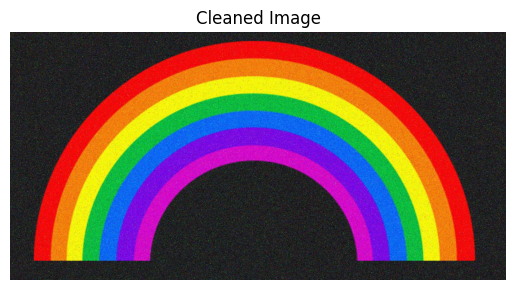

In [43]:
import matplotlib.pyplot as plt

# Step 2: Visualize the original image
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Step 3: Analyze Noise
# Simple noise detection: checking for pixels with extreme color values
# Let's say noise could be isolated very dark pixels (R, G, B all < 20) or overly bright pixels (R, G, B all > 235)
noise_condition = (df['R'] < 20) & (df['G'] < 20) & (df['B'] < 20) | (df['R'] > 235) & (df['G'] > 235) & (df['B'] > 235)
clean_df = df[~noise_condition]  # Remove noise pixels
print(clean_df.head(10))
# Step 4: Reconstruct the cleaned image
# Convert the cleaned DataFrame back to an image
cleaned_image_array = np.zeros((height, width, 3), dtype=np.uint8)
for index, row in clean_df.iterrows():
    cleaned_image_array[row['y'], row['x']] = [row['R'], row['G'], row['B']]

# Step 5: Visualize the cleaned image
cleaned_image = Image.fromarray(cleaned_image_array)
plt.imshow(cleaned_image)
plt.title('Cleaned Image')
plt.axis('off')  # Hide axes
plt.show()

In [44]:
'''The following steps are performed in the process of Visualizing and cleaning the data:
-->Original Image Visualization: The original image is displayed for reference.
Noise Detection: We identify noisy pixels based on extreme RGB values. Noisy pixels are defined as those with
either very low or very high RGB values.

-->Noise Removal: Noisy pixels are removed from the dataset, and a cleaned DataFrame (clean_df) is created that
only contains non-noisy pixels.

-->Reconstruct the Cleaned Image: Using the cleaned DataFrame, we reconstruct the image by assigning each pixel’s
RGB values to its corresponding position in the image array.

-->Cleaned Image Visualization: The cleaned image (with noise removed) is displayed to show the result.
'''

'The following steps are performed in the process of Visualizing and cleaning the data:\n-->Original Image Visualization: The original image is displayed for reference.\nNoise Detection: We identify noisy pixels based on extreme RGB values. Noisy pixels are defined as those with \neither very low or very high RGB values.\n\n-->Noise Removal: Noisy pixels are removed from the dataset, and a cleaned DataFrame (clean_df) is created that \nonly contains non-noisy pixels.\n\n-->Reconstruct the Cleaned Image: Using the cleaned DataFrame, we reconstruct the image by assigning each pixel’s \nRGB values to its corresponding position in the image array.\n\n-->Cleaned Image Visualization: The cleaned image (with noise removed) is displayed to show the result.\n'

## Task 3: KMeans Clustering with scikit-learn

### Objective
In this task, you'll apply clustering techniques to the image dataset to identify and group pixels with similar properties. The main goal is to learn how clustering can reveal patterns in data and segment the image into distinct regions based on color and position.

### Steps to Follow

1. **Standardize the Data**:
   - Choose an appropriate scaler from `scikit-learn` to standardize the pixel data, ensuring all features contribute equally to the clustering process. You may use any scaler that suits your needs (e.g., `StandardScaler`, `MinMaxScaler`).
   - *Hint*: Experimenting with different scalers can help you understand their impact on clustering results.

2. **Perform KMeans Clustering**:
   - Utilize `KMeans` from `scikit-learn` to cluster the dataset into groups. Select the number of clusters based on your analysis or experimentation.
   - *Note*: Clustering helps in understanding how data points (pixels) relate based on their features (x, y, R, G, B).

3. **Add Cluster Labels to the DataFrame**:
   - Assign the cluster labels to each pixel and append them to the DataFrame for further analysis and visualization.

4. **Visualize the Clustered Data**:
   - Use any plotting library of your choice to create a visualization that shows how the image is segmented into clusters.
   - *Tip*: Customize your plots to highlight the clusters effectively (e.g., color coding based on cluster labels).

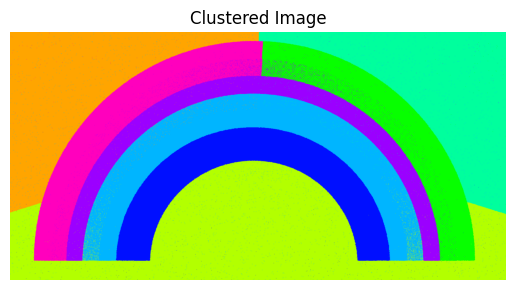

    R   G   B  x  y  cluster
0  68  67  49  0  0        0
1  42  43  27  1  0        0
2  43  43  31  2  0        0
3  34  35  27  3  0        0
4  50  49  44  4  0        0


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


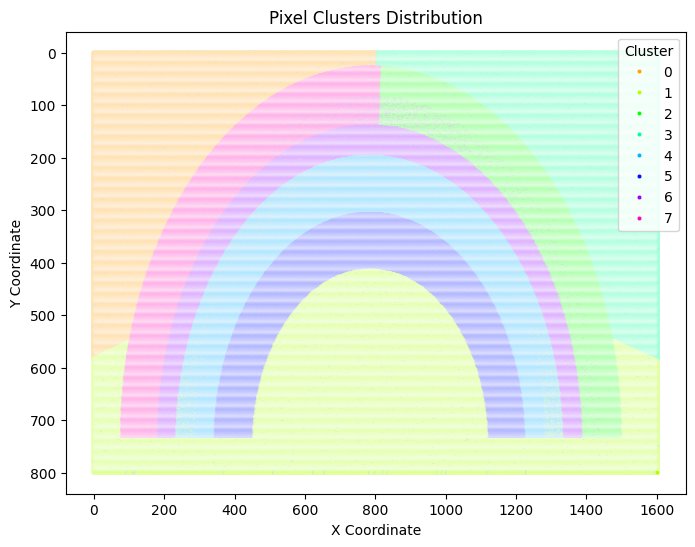

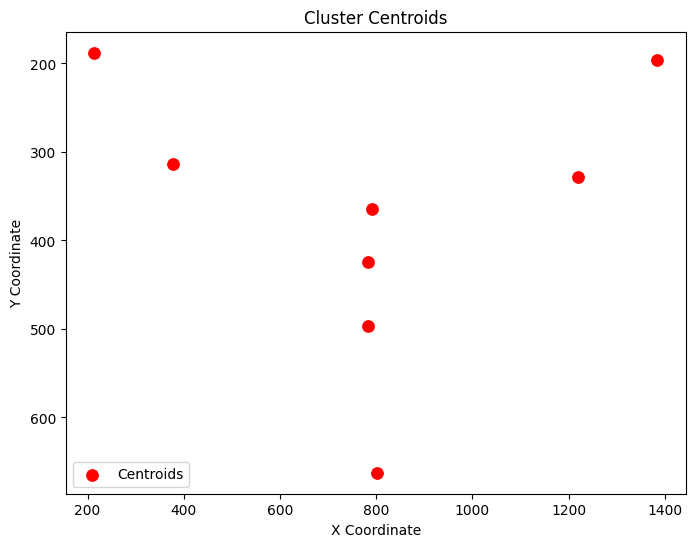

In [45]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Standardize the Data
# Extract the features (x, y, R, G, B)
features = df[['x', 'y', 'R', 'G', 'B']].values

scaler = MinMaxScaler()
#scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply Clustering
# Choose the number of clusters (e.g., 5 for segmentation into 5 regions)
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(scaled_features)

# Assign cluster labels to each pixel
df['cluster'] = kmeans.labels_

# Visualize Clusters

# Create a color palette for clusters
import seaborn as sns
palette = sns.color_palette('cubehelix', n_colors=8)
palette = sns.color_palette('hsv', n_colors=8)


# Create a new image to visualize clusters
cluster_image_array = np.zeros((height, width, 3), dtype=np.uint8)

for index, row in df.iterrows():
    cluster_color = (np.array(palette[row['cluster']]) * 255).astype(int)
    cluster_image_array[int(row['y']), int(row['x'])] = cluster_color

# Visualize the clustered image
clustered_image = Image.fromarray(cluster_image_array)
plt.imshow(clustered_image)
plt.title('Clustered Image')
plt.axis('off')
plt.show()

# Inspect Clustered Data
# Print the first few rows of the DataFrame with cluster assignments
print(df.head())

# Additional Visualization: Cluster Distributions
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['x'], y=df['y'], hue=df['cluster'], palette=palette, s=10, legend='full'
)
plt.gca().invert_yaxis()  # Invert y-axis to match image origin
plt.title('Pixel Clusters Distribution')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend(title='Cluster')
plt.show()

# Additional Visualization: Cluster Centroids
centroids = kmeans.cluster_centers_
scaled_centroids = scaler.inverse_transform(centroids)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=scaled_centroids[:, 0], y=scaled_centroids[:, 1], color='red', s=100, label='Centroids'
)
plt.gca().invert_yaxis()
plt.title('Cluster Centroids')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.show()

In [46]:
'''This challenge involved using clustering techniques to the pixel data collected from the rainbow image in order
 to group pixels with similar qualities. The KMeans clustering technique was utilized to accomplish this.

Steps Completed:

    - The data was normalized using scikit-learn's MinMaxScaler, which scales features from 0 to 1.
    This ensures an equal contribution from all features.
    - The scaled data was analyzed using the KMeans algorithm with eight clusters.
    - The number of clusters was determined by several experiments.
    KMeans divided pixels into different clusters based on their color and spatial features.
    - KMeans-assigned cluster labels were added to the original dataframe, allowing for additional analysis and
    visualization.

The problem faced during k means clustering is that clustering is done using five features: x, y, R, G, and B.
These features combine spatial and color information, which may result in the creation of clusters in a
high-dimensional space. This can make clustering less intuitive to perceive, especially when plotted with simply x
and y values.
The choice of n_clusters=8 may not be ideal for all datasets. It's a heuristic choice, and in reality, establishing
the appropriate number of clusters (using methods like the elbow method or silhouette score) may improve results.
So using different colour palattes can help make it look appealing.
'''


"This challenge involved using clustering techniques to the pixel data collected from the rainbow image in order\n to group pixels with similar qualities. The KMeans clustering technique was utilized to accomplish this.\n\nSteps Completed:\n\n    - The data was normalized using scikit-learn's MinMaxScaler, which scales features from 0 to 1. \n    This ensures an equal contribution from all features.\n    - The scaled data was analyzed using the KMeans algorithm with eight clusters.\n    - The number of clusters was determined by several experiments.\n    KMeans divided pixels into different clusters based on their color and spatial features.\n    - KMeans-assigned cluster labels were added to the original dataframe, allowing for additional analysis and \n    visualization.\n\nThe problem faced during k means clustering is that clustering is done using five features: x, y, R, G, and B. \nThese features combine spatial and color information, which may result in the creation of clusters i

## Task 4: Custom Clustering Algorithm with PyTorch

### Objective
In this task, you'll take a step beyond pre-built libraries and implement your own clustering algorithm using PyTorch. This exercise will help you understand the mechanics of clustering and give you a deeper appreciation for how these algorithms work under the hood.

### Steps to Follow

1. **Prepare the Data**:
   - Ensure that the data is in a format suitable for PyTorch (i.e., convert the relevant DataFrame columns to PyTorch tensors).
   - Scale the features as needed. You can apply any scaling or normalization strategy you find useful.

2. **Initialize Centroids**:
   - Randomly select initial centroids from the dataset. The number of clusters should be chosen based on your analysis (e.g., 8 clusters).

3. **Implement the Clustering Algorithm**:
   - Create a loop for a set number of iterations:
     - **Calculate Distances**: Compute the distance from each data point to each centroid.
     - **Assign Labels**: Assign each data point to the nearest centroid.
     - **Update Centroids**: Recompute each centroid as the mean of all points assigned to it.
   - *Hint*: Use `torch.cdist()` for distance calculation and `torch.mean()` for centroid updates.

4. **Add Cluster Labels to the DataFrame**:
   - Convert the computed cluster labels from PyTorch tensors back to a format that can be added to the DataFrame for visualization.

5. **Visualize the Clusters**:
   - Plot the clustered image data to show how the pixels are grouped. Use any visualization library you prefer.

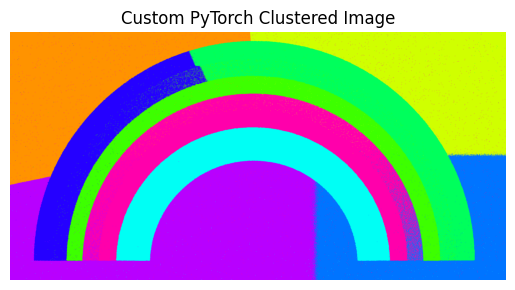

In [47]:
import torch

# Standardize the Data
# Extract the features (x, y, R, G, B)
features = df[['x', 'y', 'R', 'G', 'B']].values

scaler = MinMaxScaler()
#scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Implement Custom Clustering with PyTorch
torch_features = torch.tensor(scaled_features, dtype=torch.float32)

# Initialize centroids (randomly select from data points)
k = 9  # Number of clusters
indices = torch.randperm(torch_features.size(0))[:k]
centroids = torch_features[indices]

# Clustering loop
n_iterations = 15
for _ in range(n_iterations):
    # Compute distances from each point to each centroid
    distances = torch.cdist(torch_features, centroids)

    # Assign each point to the nearest centroid
    labels = torch.argmin(distances, dim=1)

    # Update centroids as the mean of assigned points
    new_centroids = torch.stack([
        torch_features[labels == i].mean(dim=0) if (labels == i).sum() > 0 else centroids[i]
        for i in range(k)
    ])

    # Check for convergence (optional)
    if torch.allclose(centroids, new_centroids):
        break
    centroids = new_centroids

# Add cluster labels to DataFrame
df['torch_cluster'] = labels.numpy()

# Visualize the custom clustering results
palette_torch = sns.color_palette('hsv', n_colors=k)

# Create a new image for PyTorch clusters
torch_cluster_image_array = np.zeros((height, width, 3), dtype=np.uint8)

for index, row in df.iterrows():
    cluster_color = (np.array(palette_torch[row['torch_cluster']]) * 255).astype(int)
    torch_cluster_image_array[int(row['y']), int(row['x'])] = cluster_color

# Visualize the PyTorch clustered image
torch_clustered_image = Image.fromarray(torch_cluster_image_array)
plt.imshow(torch_clustered_image)
plt.title('Custom PyTorch Clustered Image')
plt.axis('off')
plt.show()

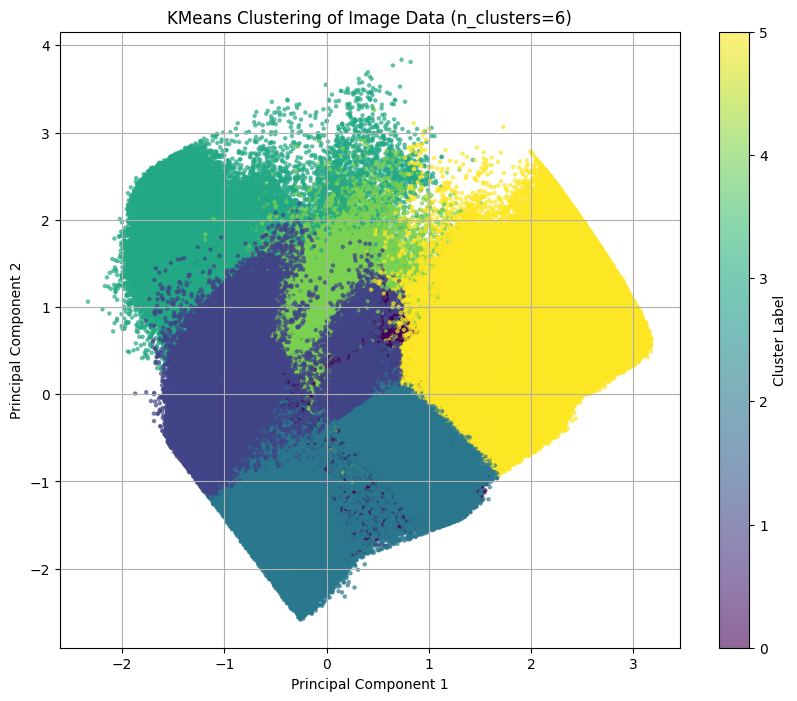

In [48]:
# Step 6: Perform KMeans clustering
n_clusters = 6  # Number of clusters, you can adjust this
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Step 7: Apply PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 8: Visualize the clustering results on a 2D scatter plot
plt.figure(figsize=(10, 8))

# Scatter plot of the PCA-reduced data points
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', s=5, alpha=0.6)

# Add title and labels
plt.title(f'KMeans Clustering of Image Data (n_clusters={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Show the plot
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()


In [49]:
'''The last job involves creating a unique clustering algorithm in PyTorch to categorize pixels in the rainbow
image based on color and spatial characteristics. This task helped me understand the mechanics of clustering to see
how actually the algorithm works in the backend.

Steps completed:

    - The required features were extracted from the DataFrame.
    - To ensure consistent grouping, the MinMaxScaler from scikit-learn was used to scale the features from 0 to 1.
    - This scaled data was turned to a PyTorch tensor for faster calculation.
    - The randperm function in PyTorch was used to select K=9 random data points as the dataset's starting centroids.
    - These centroids served as the beginning points for grouping.
    The clustering technique was implemented as a loop with a set number of iterations to refine the groupings.
    -The Euclidean distance between each data point and all centroids was calculated using torch.cdist.
    - Each pixel was assigned to the centroid with the shortest distance.
    - The clustered image was reconstructed, with each cluster allocated a distinct color from a predetermined
    palette (hsv).
    - Finally, the clustered image was visualized with matplotlib.

Finally, a k-means clustering graph was plotted with dimensionality reduction for detailed view of clustering.

Project completed by: Dhwani Patel
  '''

"The last job involves creating a unique clustering algorithm in PyTorch to categorize pixels in the rainbow \nimage based on color and spatial characteristics.\n\nSteps completed:\n\n    - The required features were extracted from the DataFrame.\n    - To ensure consistent grouping, the MinMaxScaler from scikit-learn was used to scale the features from 0 to 1.\n    - This scaled data was turned to a PyTorch tensor for faster calculation.\n    - The randperm function in PyTorch was used to select K=9 random data points as the dataset's starting centroids.\n    - These centroids served as the beginning points for grouping.\n    The clustering technique was implemented as a loop with a set number of iterations to refine the groupings.\n    -The Euclidean distance between each data point and all centroids was calculated using torch.cdist.\n    - Each pixel was assigned to the centroid with the shortest distance.\n    - The clustered image was reconstructed, with each cluster allocated a d